# Практическое задание №3: Классификация мест залежей нефти и газа


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)

In [2]:
import kagglehub

path = kagglehub.competition_download('classification-of-oil-and-gas')
print(os.listdir(path))

train = pd.read_csv(os.path.join(path, 'train_oil.csv'))
test  = pd.read_csv(os.path.join(path, 'oil_test.csv'))

print(train.shape, test.shape)

100%|██████████| 24.4k/24.4k [00:00<00:00, 15.7MB/s]

Extracting files...
['train_oil.csv', 'oil_test.csv']
(309, 20) (133, 19)


## EDA


In [3]:
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [5]:
train.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
count,282.00000,279.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.62426,-12.508435,6755.669903,760.087379,183.683236,17.825178,476.994757
std,22.19116,86.387220,3628.094135,1353.934404,282.252489,7.171048,1000.140605
min,-38.39890,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000
25%,28.24915,-102.336500,4059.000000,128.000000,45.000000,12.000000,10.000000
50%,38.13500,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000
75%,52.13360,56.179900,9186.000000,715.000000,205.000000,23.600000,390.000000
max,76.44620,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000


In [6]:
train.isnull().mean().sort_values(ascending=False).head(10)

,0
Region,0.122977
Basin name,0.122977
Longitude,0.097087
Country,0.087379
Latitude,0.087379
Reservoir unit,0.000000
Field name,0.000000
Tectonic regime,0.000000
Operator company,0.000000
Onshore/Offshore,0.000000


In [7]:
print(train['Onshore/Offshore'].value_counts())

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64


In [8]:
train['Onshore/Offshore'] = train['Onshore/Offshore'].replace('ONSHORE-OFFSHORE', 'ONSHORE')
print(train['Onshore/Offshore'].value_counts())

Onshore/Offshore
ONSHORE     223
OFFSHORE     86
Name: count, dtype: int64


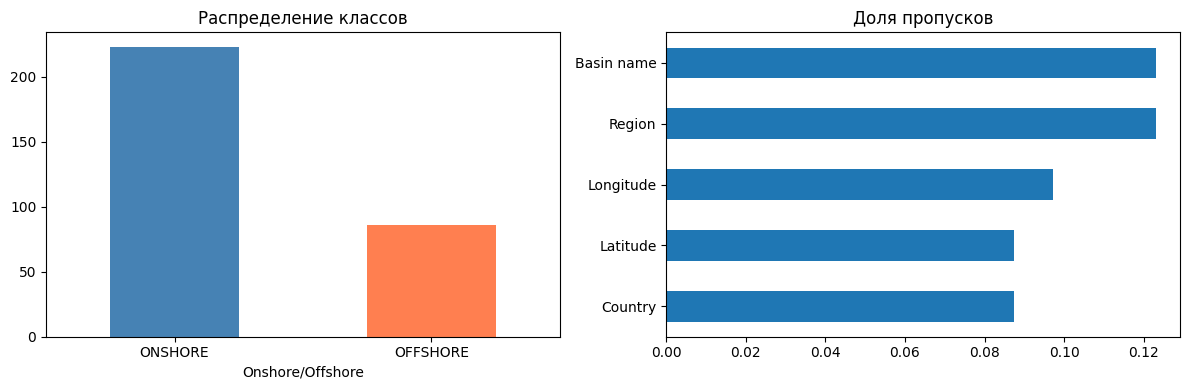

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['Onshore/Offshore'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Распределение классов')
axes[0].tick_params(axis='x', rotation=0)

missing = train.isnull().mean()
missing = missing[missing > 0].sort_values()
missing.plot(kind='barh', ax=axes[1])
axes[1].set_title('Доля пропусков')

plt.tight_layout()
plt.show()

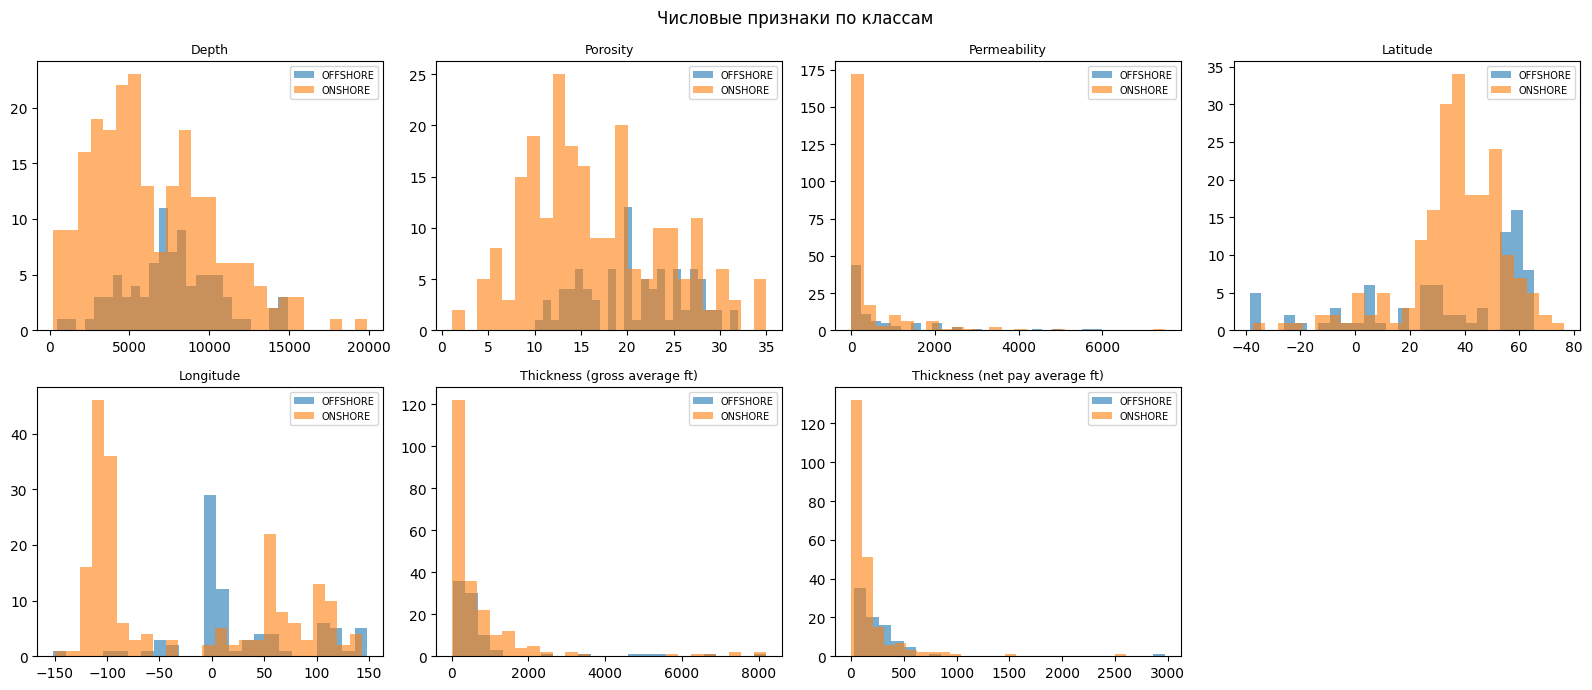

In [10]:
num_cols = ['Depth', 'Porosity', 'Permeability', 'Latitude', 'Longitude',
            'Thickness (gross average ft)', 'Thickness (net pay average ft)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in train.groupby('Onshore/Offshore'):
        axes[i].hist(grp[col].dropna(), bins=25, alpha=0.6, label=label)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Числовые признаки по классам')
plt.tight_layout()
plt.show()

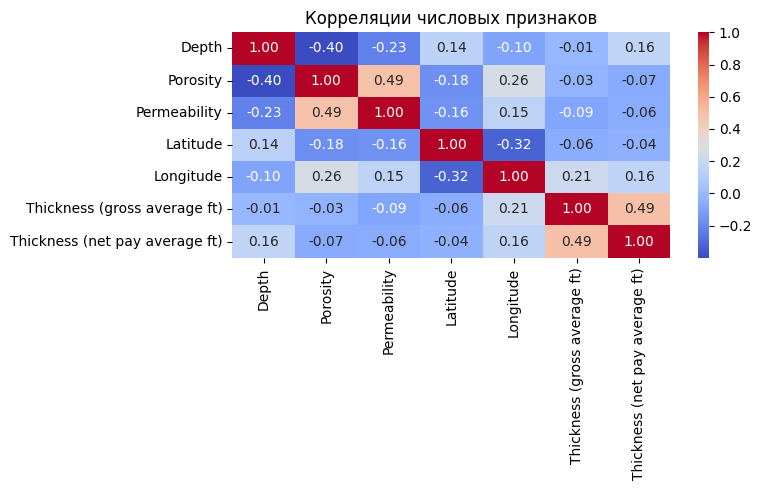

In [11]:
corr = train[num_cols].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции числовых признаков')
plt.tight_layout()
plt.show()

**Вывод:** Датасет небольшой, 309 строк и 20 признаков. Сразу бросилось в глаза что таргет оказался не бинарным, есть третий класс ONSHORE-OFFSHORE, 5 штук всего. Такое модель не выучит, поэтому объединил их с ONSHORE, геологически это оправдано. Пропуски только в географических признаках, до 12%, ничего критичного. По гистограммам видно что Latitude и Longitude неплохо разделяют классы, а вот Depth и Porosity различаются не так явно.

## Предобработка

In [12]:
TARGET = 'Onshore/Offshore'
DROP_COLS = ['Field name', 'Reservoir unit', 'Operator company']

X = train.drop(columns=[TARGET] + DROP_COLS)
y = train[TARGET]

X_test_raw = test.drop(columns=DROP_COLS, errors='ignore')

print('X shape:', X.shape)
print(y.value_counts())

X shape: (309, 16)
Onshore/Offshore
ONSHORE     223
OFFSHORE     86
Name: count, dtype: int64


In [13]:
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)
print('Классы:', le_target.classes_)

Классы: ['OFFSHORE' 'ONSHORE']


In [14]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols_proc = X.select_dtypes(exclude='object').columns.tolist()

print('Категориальные:', cat_cols)
print('Числовые:', num_cols_proc)

Категориальные: ['Country', 'Region', 'Basin name', 'Tectonic regime', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']
Числовые: ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']


In [15]:
X_all = pd.concat([X, X_test_raw], axis=0).reset_index(drop=True)
n_train = len(X)

for col in num_cols_proc:
    X_all[col] = X_all[col].fillna(X_all[col].median())

le_dict = {}
for col in cat_cols:
    X_all[col] = X_all[col].fillna(X_all[col].mode()[0])
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))
    le_dict[col] = le

print('Пропуски после обработки:', X_all.isnull().sum().sum())

Пропуски после обработки: 0


In [16]:
X_proc      = X_all.iloc[:n_train].reset_index(drop=True)
X_test_proc = X_all.iloc[n_train:].reset_index(drop=True)

X_train, X_val, y_train, y_val = train_test_split(
    X_proc, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print('Train:', X_train.shape, 'Val:', X_val.shape)

Train: (247, 16) Val: (62, 16)


**Вывод:** Удалил три колонки: Field name и Reservoir unit это просто идентификаторы, а Operator company содержит слишком много уникальных значений и плохо обобщается. Пропуски заполнил медианой для числовых и модой для категориальных. Кодирование делал на объединённом train+test чтобы не словить проблему с новыми категориями в тесте.

## Feature Engineering

In [17]:
def add_features(df):
    df = df.copy()

    df['net_to_gross'] = df['Thickness (net pay average ft)'] / (df['Thickness (gross average ft)'] + 1e-6)

    df['log_permeability'] = np.log1p(df['Permeability'].clip(lower=0))

    df['log_depth'] = np.log1p(df['Depth'].clip(lower=0))

    df['abs_latitude'] = df['Latitude'].abs()

    return df

X_train_fe = add_features(X_train)
X_val_fe   = add_features(X_val)
X_test_fe  = add_features(X_test_proc)

print('Итого признаков:', X_train_fe.shape[1])

Итого признаков: 20


**Вывод:** Добавил четыре новых признака. net_to_gross это стандартный петрофизический показатель, характеризует долю продуктивной части пласта. log_permeability и log_depth нужны потому что у этих признаков сильно скошенное распределение, логарифм его выравнивает. abs_latitude добавил исходя из логики что шельфовые месторождения географически кластеризованы в определённых широтах. В итоге 20 признаков вместо 16.

## Обучение и сравнение моделей

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_fe)
X_val_sc   = scaler.transform(X_val_fe)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'), True),
    'DecisionTree':       (DecisionTreeClassifier(random_state=SEED, class_weight='balanced'), False),
    'KNN':                (KNeighborsClassifier(n_neighbors=5), True),
    'RandomForest':       (RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1), False),
    'GradientBoosting':   (GradientBoostingClassifier(n_estimators=200, random_state=SEED), False),
}

results = []
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train_fe.values
    Xvl = X_val_sc   if use_scaled else X_val_fe.values

    model.fit(Xtr, y_train)
    val_pred  = model.predict(Xvl)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    results.append({
        'model': name,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'val_acc': accuracy_score(y_val, val_pred)
    })
    print(f'{name:<22} CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  val: {accuracy_score(y_val, val_pred):.4f}')

res = pd.DataFrame(results).sort_values('val_acc', ascending=False)
res

LogisticRegression     CV: 0.8462 ± 0.0240  val: 0.7903
DecisionTree           CV: 0.8544 ± 0.0411  val: 0.8387
KNN                    CV: 0.8299 ± 0.0212  val: 0.8226
RandomForest           CV: 0.8745 ± 0.0232  val: 0.9032
GradientBoosting       CV: 0.8786 ± 0.0120  val: 0.8387


,model,cv_mean,cv_std,val_acc
3,RandomForest,0.874531,0.023244,0.903226
4,GradientBoosting,0.878612,0.012041,0.838710
1,DecisionTree,0.854367,0.041060,0.838710
2,KNN,0.829878,0.021224,0.822581
0,LogisticRegression,0.846204,0.023966,0.790323


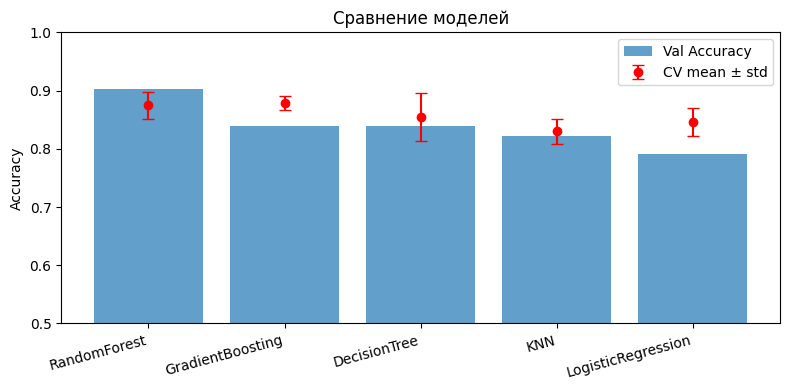

In [19]:
plt.figure(figsize=(8, 4))
x = range(len(res))
plt.bar(x, res['val_acc'], alpha=0.7, label='Val Accuracy')
plt.errorbar(x, res['cv_mean'], yerr=res['cv_std'], fmt='o', color='red', capsize=4, label='CV mean ± std')
plt.xticks(x, res['model'], rotation=15, ha='right')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.title('Сравнение моделей')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** Random Forest показал лучший результат и по CV и по validation accuracy. Gradient Boosting CV даже чуть выше, но на val уступает. Логистическая регрессия предсказуемо проигрывает, линейная граница решения здесь не подходит. Для тюнинга берём Random Forest.

## Подбор гиперпараметров (Random Forest)

In [20]:
param_grid = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight='balanced', n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train_fe, y_train)

print('Лучшие параметры:', gs.best_params_)
print('CV score:        ', round(gs.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
CV score:         0.8826


In [21]:
best = gs.best_estimator_
val_pred_best = best.predict(X_val_fe)

print('Val accuracy после тюнинга:', round(accuracy_score(y_val, val_pred_best), 4))
print()
print(classification_report(y_val, val_pred_best, target_names=le_target.classes_))

Val accuracy после тюнинга: 0.8871

              precision    recall  f1-score   support

    OFFSHORE       0.81      0.76      0.79        17
     ONSHORE       0.91      0.93      0.92        45

    accuracy                           0.89        62
   macro avg       0.86      0.85      0.86        62
weighted avg       0.89      0.89      0.89        62



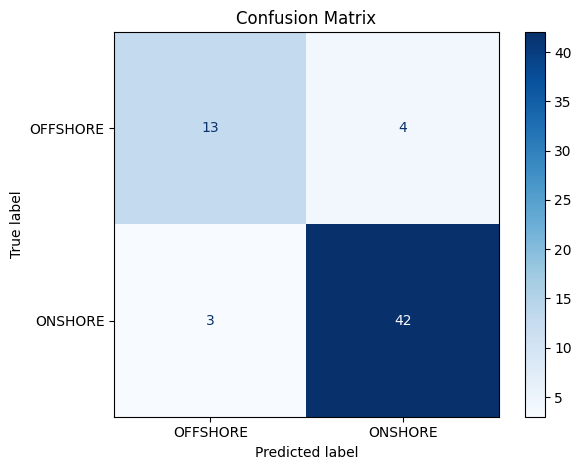

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred_best,
    display_labels=le_target.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

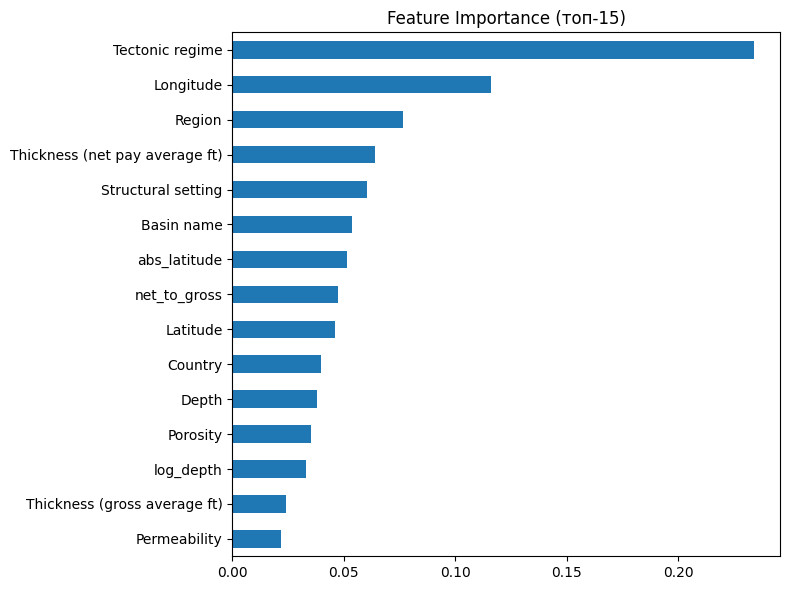

Tectonic regime                   0.233945
Longitude                         0.116069
Region                            0.076554
Thickness (net pay average ft)    0.063965
Structural setting                0.060495
Basin name                        0.053615
abs_latitude                      0.051607
net_to_gross                      0.047271
Latitude                          0.046022
Country                           0.039831
dtype: float64


In [23]:
feat_imp = pd.Series(best.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance (топ-15)')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

**Вывод:** GridSearchCV подобрал оптимальные параметры, val accuracy вырос до 0.89. Самый важный признак Tectonic regime, что логично, тектонический режим напрямую связан с типом залежи. На втором месте Longitude, морские месторождения концентрируются в конкретных регионах вроде Северного моря и Персидского залива. Из сгенерированных признаков в топ вошёл net_to_gross, значит feature engineering себя оправдал.

## Предсказание и submission

In [24]:
X_full_fe = add_features(X_proc)
best.fit(X_full_fe, y_enc)

preds = le_target.inverse_transform(best.predict(X_test_fe))
print(pd.Series(preds).value_counts())

ONSHORE     102
OFFSHORE     31
Name: count, dtype: int64


**Вывод:** Обнаружил третий класс ONSHORE-OFFSHORE и объединил его с ONSHORE. Удалил идентификаторы и признаки с высокой кардинальностью. Добавил 4 новых признака, один из которых попал в топ по важности. Протестировал 5 моделей, лучший результат у Random Forest: CV 0.88, val accuracy 0.89 после тюнинга. Наиболее значимые признаки соответствуют геологической логике задачи.

## Скриншот с лидерборда Kaggle

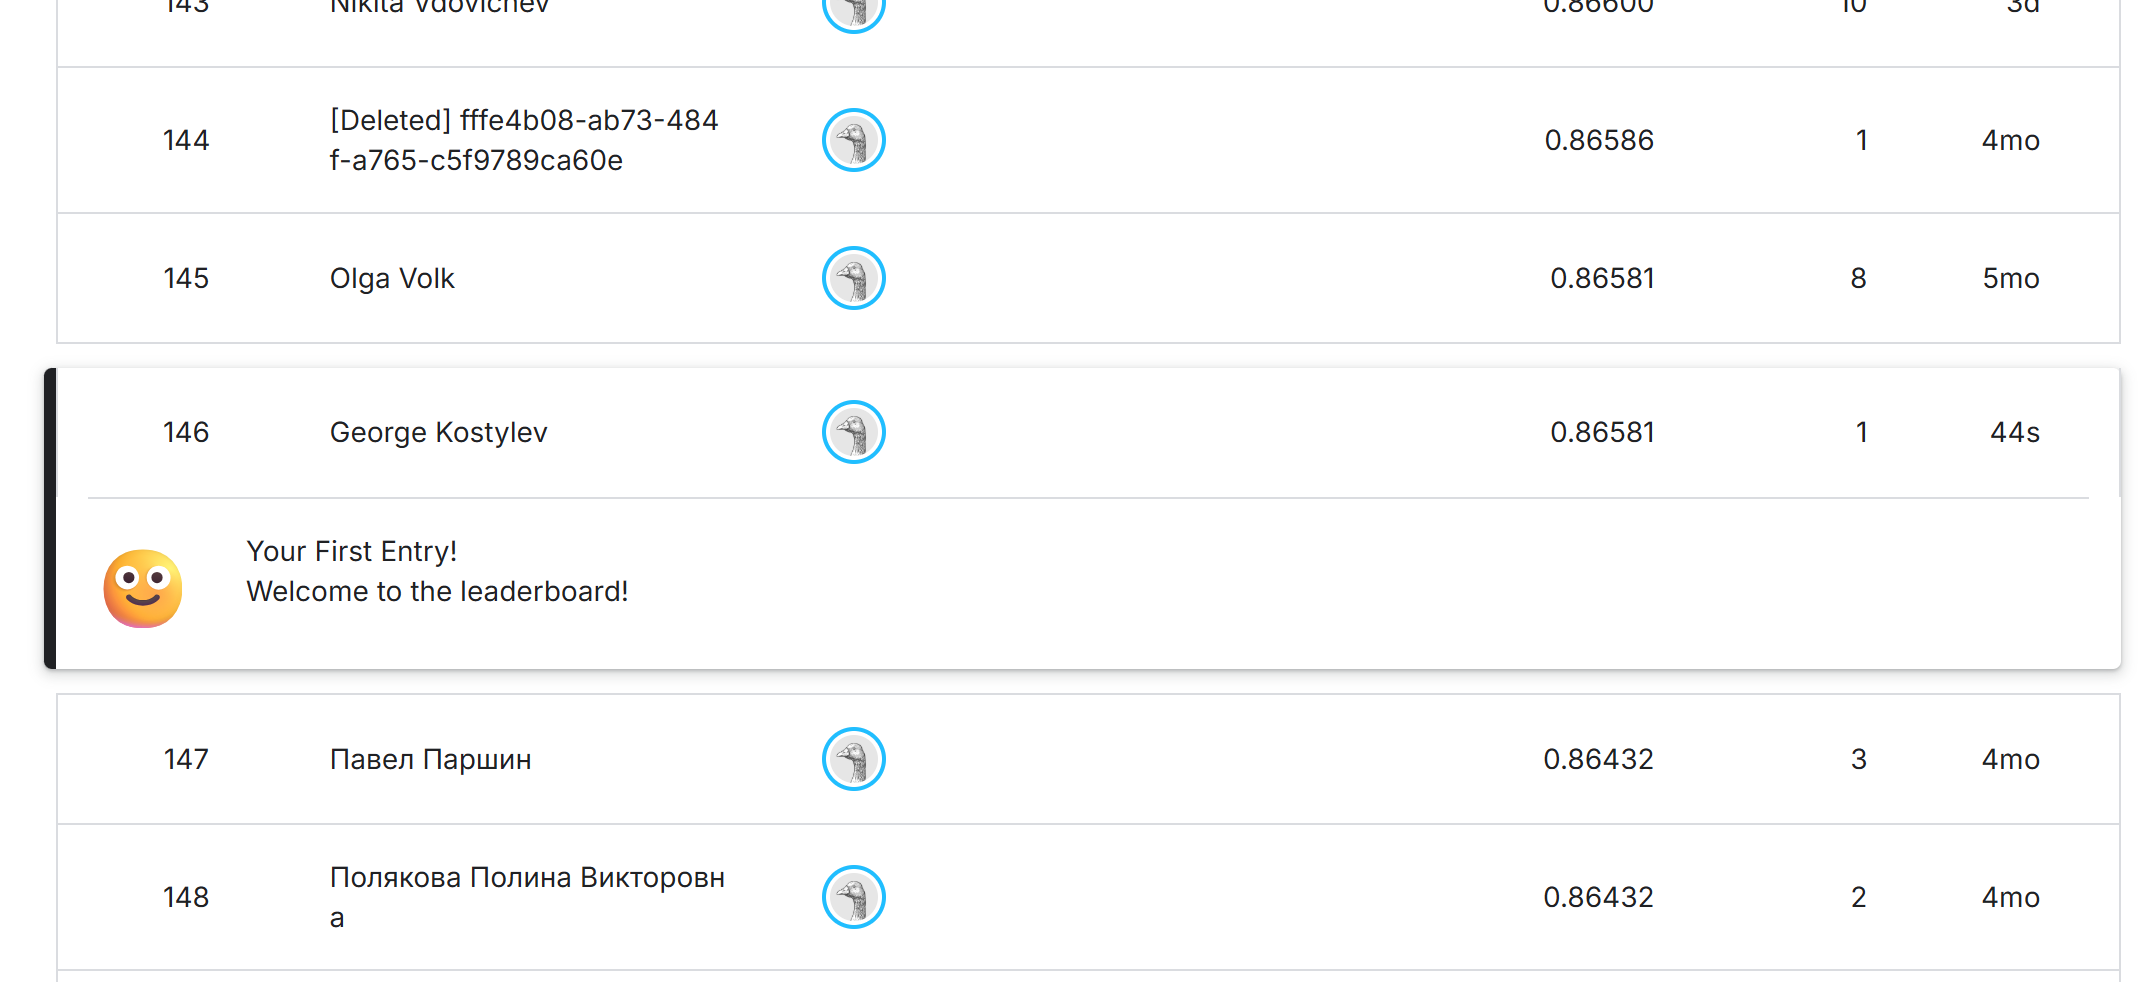